# What drives Airbnb prices in Porto? A Data-driven Analysis

**Author**: Carolina Dias | **Dataset:** Inside Airbnb - Porto listings | **Date:** 2026

---

## Overview

Tourism in Portugal has been growing considerably in the last decade, and Porto is one of the most popular destinations. With thousands of listings spread across 17 municipalities, from the tourist-dense historic centre to quieter coastal towns, understanding what drives accomodation prices is valuable for hosts, guests, and investors alike.

This notebook investigates:
1. **What factors most influence listing prices** (room type, neighbourhood, host type)
2. **How host behaviour clusters** across the market (professional vs. casual operators)
3. **Whether we can predict price** and identify listings that over- or under-charge relative to their characteristics

**Key findings are summarised in the [Conclusions](#conclusions) section at the end.**

In [92]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.transforms as transforms 
import seaborn as sns
import geopandas as gpd
from dash import Dash,dcc,html,Input,Output
import plotly.express as px
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors


# Import dataset
porto = pd.read_csv("data/listings.csv")
neigh = pd.read_csv("data/neighbourhoods.csv")
porto = porto.copy()

## Data Inspection

In [93]:
# 1. Data Inspection
porto.head(n=3)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,41339,Porto city flat near the sea,180050,Paula,PORTO,Lordelo do Ouro e Massarelos,41.15010,-8.66035,Entire home/apt,69.0,2,33,2025-09-09,0.22,1,98,8,29049/AL
1,55111,Fontielas Houses |Floor1 in House with shared ...,259711,Isabel E João,PAREDES,Cete,41.17418,-8.35533,Entire home/apt,NaN,5,21,2025-08-30,0.17,3,0,1,7563/AL
2,73828,Fontielas Houses |Floor0 in House with shared ...,259711,Isabel E João,PAREDES,Cete,41.17622,-8.35351,Entire home/apt,NaN,5,20,2025-08-31,0.16,3,0,5,7563/AL


In [94]:
print(porto.info(),"\n")
print(porto.describe())

<class 'pandas.DataFrame'>
RangeIndex: 14806 entries, 0 to 14805
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              14806 non-null  int64  
 1   name                            14806 non-null  str    
 2   host_id                         14806 non-null  int64  
 3   host_name                       14805 non-null  str    
 4   neighbourhood_group             14806 non-null  str    
 5   neighbourhood                   14806 non-null  str    
 6   latitude                        14806 non-null  float64
 7   longitude                       14806 non-null  float64
 8   room_type                       14806 non-null  str    
 9   price                           13192 non-null  float64
 10  minimum_nights                  14806 non-null  int64  
 11  number_of_reviews               14806 non-null  int64  
 12  last_review                     13305 non-n

## Data Filtering and Cleaning

We drop columns that carry no analytical value, remove unavailable listings,
and cap outliers in `minimum_nights` (≤ 3 nights covers the 3rd quartile) and `price` (≤ €500 removes <1% of listings but eliminates luxury noise).

In [95]:
# Remove unnecessary columns
cols_to_drop = ["name", "host_id", "host_name", "reviews_per_month", "last_review", "number_of_reviews_ltm", "license"]
porto_df = porto.drop(columns=cols_to_drop, inplace=False)

## Remove unavailable listings
porto_df = porto_df[porto_df["availability_365"] > 0]

# porto_df.head(n=5) 

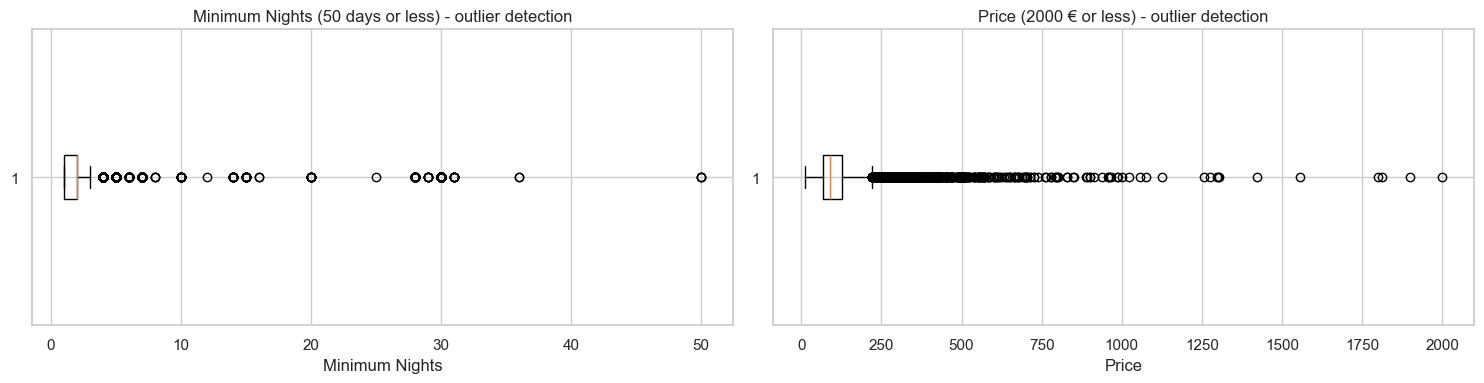

In [96]:
## Minimum_nights - outlier detection
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

axes[0].boxplot(porto_df[porto_df["minimum_nights"] <= 50]["minimum_nights"], vert=False)
axes[0].set_xlabel("Minimum Nights")
axes[0].set_title("Minimum Nights (50 days or less) - outlier detection")

# Price - outlier detection
axes[1].boxplot(porto_df[porto_df["price"] <= 2000]["price"], vert=False)
axes[1].set_xlabel("Price")
axes[1].set_title("Price (2000 € or less) - outlier detection")

plt.tight_layout()
plt.show()


In [97]:
# Removing minimum_nights outliers
porto_df = porto_df[porto_df["minimum_nights"] <= 3] ## 3rd quantile = 2 days so limit is set to 3 days

# Price filtering
porto_df = porto_df[porto_df["price"] <= 500]

# Remove price NaN values
porto_df = porto_df.dropna(subset=["price"])

In [98]:
# Check final dataset
porto_df.info()

# Obs: filtered dataset has no null values

<class 'pandas.DataFrame'>
Index: 12007 entries, 0 to 14805
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              12007 non-null  int64  
 1   neighbourhood_group             12007 non-null  str    
 2   neighbourhood                   12007 non-null  str    
 3   latitude                        12007 non-null  float64
 4   longitude                       12007 non-null  float64
 5   room_type                       12007 non-null  str    
 6   price                           12007 non-null  float64
 7   minimum_nights                  12007 non-null  int64  
 8   number_of_reviews               12007 non-null  int64  
 9   calculated_host_listings_count  12007 non-null  int64  
 10  availability_365                12007 non-null  int64  
dtypes: float64(3), int64(5), str(3)
memory usage: 1.1 MB


After careful data preparation, 12007 observations remain. Next, we look at the dataset and create new variables to facilitate our analysis.

## Feature Engineering

We create two derived features:
- **`total_min_cost`** — the minimum spend a guest must commit to (`price × minimum_nights`), a better proxy for actual cost than price alone.
- **`professional_host`** — a boolean flag for hosts with more than 3 listings, consistent with Inside Airbnb's definition of commercial operators.

In [99]:
# Feature engineering

## Minimum nights * price = total minimum cost to stay
porto_df["total_min_cost"] = porto_df["minimum_nights"] * porto_df["price"]

In [100]:
# Classification - professional hosts vs casual hosts

# Feature engineering - professional host
porto_df["professional_host"] = (porto_df["calculated_host_listings_count"] > 3)

## Exploratory Data Analysis

### 4.1 Price & Cost Distributions

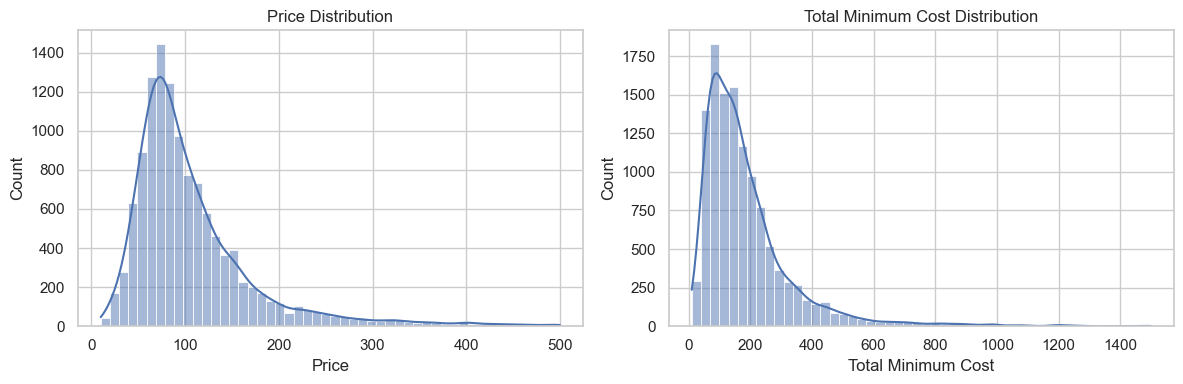

In [101]:
# price and total_min_cost distribution

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(porto_df["price"], bins=50, kde=True, ax=axes[0])
axes[0].set_xlabel("Price")
axes[0].set_title("Price Distribution")

sns.histplot(porto_df["total_min_cost"], bins=50, kde=True, ax=axes[1])
axes[1].set_xlabel("Total Minimum Cost")
axes[1].set_title("Total Minimum Cost Distribution")

plt.tight_layout()
plt.show()


### 4.2. Listings by Neighboourhood and Room Type

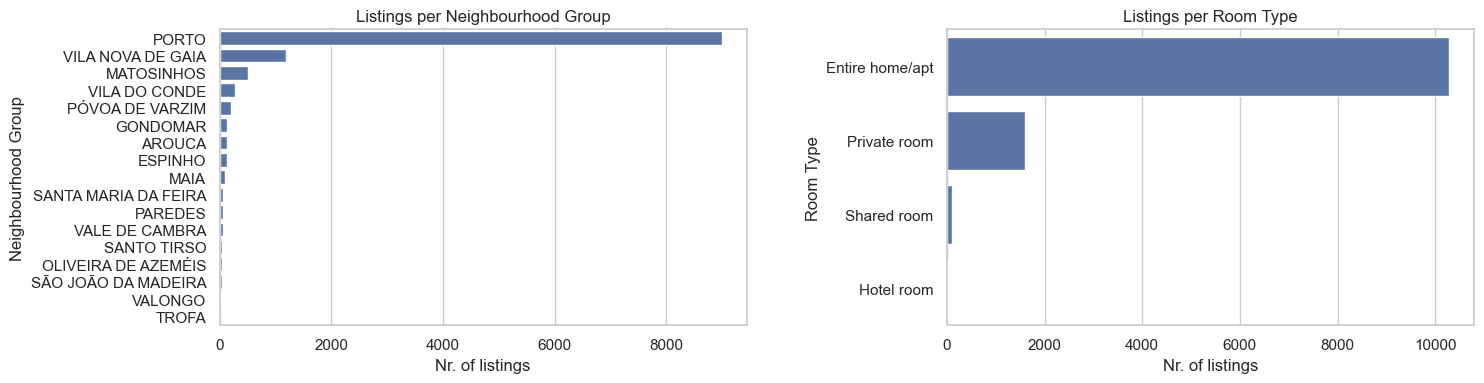

In [102]:
# number of listings by neighbourhood group + room type
counts = porto_df.groupby("neighbourhood_group").size().reset_index(name="count")
counts = counts.sort_values(by="count", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
sns.barplot(data=counts, y="neighbourhood_group", x="count", order=counts["neighbourhood_group"], ax = axes[0])
axes[0].set_xlabel("Nr. of listings")
axes[0].set_ylabel("Neighbourhood Group")
axes[0].set_title("Listings per Neighbourhood Group")


# number of listings by room type
counts_room = porto_df.groupby("room_type").size().reset_index(name="count")
counts_room = counts_room.sort_values(by="count", ascending=False)
sns.barplot(data=counts_room, y="room_type", x="count", order=counts_room["room_type"], ax = axes[1])
axes[1].set_xlabel("Nr. of listings")
axes[1].set_ylabel("Room Type")
axes[1].set_title("Listings per Room Type")

plt.tight_layout()
plt.subplots_adjust(wspace=0.38)   
plt.show()


### 4.3 Price Distribution Across Municipalities

The ridge plot below shows how price distributions differ across all 17 municipalities.
The vertical black line marks each area's **median price**. We would expect to observe the **highest** prices in the most **touristic** municipalities, such as Porto and Matosinhos. Yet, results show otherwise - Matosinhos is the 5th cheapest municipality and Porto is in middle rank. Conversely, **Trofa** and **Santo Tirso** stand out as the two most **expensive** regions, which interestingly are outside Porto's metropolitan area. 

It's worth noting that **number of listings** play an important role in the results we observed. Porto, having the most accomodation density, follows a normal distribution. In contrast, São João da Madeira, Valongo and Trofa have very few listings.

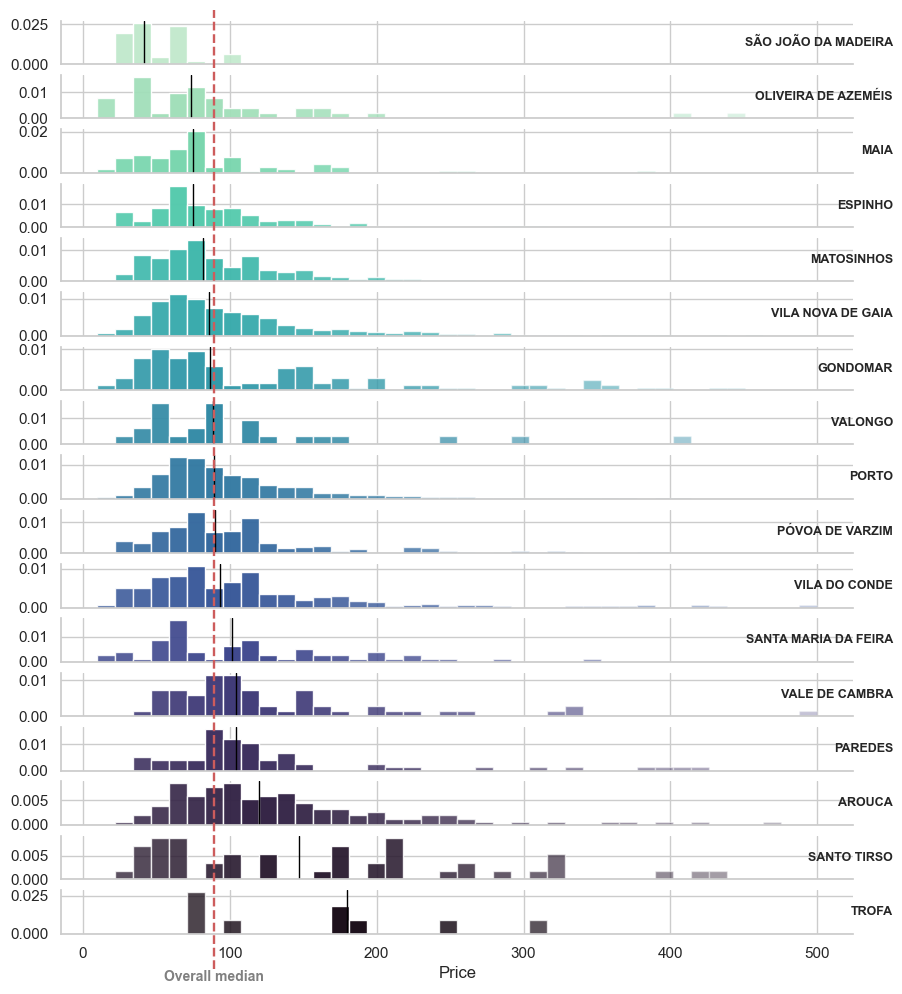

In [103]:
overall_median = porto_df['price'].median()
order = (porto_df.groupby('neighbourhood_group')['price'].median().sort_values().index)
global_bins = np.histogram_bin_edges(porto_df['price'], bins=40)

palette = sns.color_palette("mako", len(order))
palette = list(reversed(palette))
pal_dict = dict(zip(order, palette))

g = sns.FacetGrid(porto_df, row="neighbourhood_group", row_order=order,
    hue="neighbourhood_group", palette=pal_dict, height=0.6, aspect=15, sharex=True, sharey=False)

g.map(sns.histplot, "price", bins=global_bins, stat='density', alpha=0.9)
g.figure.subplots_adjust(hspace=0.25)

for ax, neigh in zip(g.axes.flat, order):
    neigh_median = porto_df.loc[porto_df['neighbourhood_group'] == neigh,'price'].median()
    ax.axvline(neigh_median, linewidth=1, color='black')
    ax.text(1.05, 0.5, neigh, transform=ax.transAxes, ha='right', va='center', fontsize=9, fontweight='bold')
    ax.set_title("")
    patches = ax.patches
    
    if patches:
        centers = [
            p.get_x() + p.get_width()/2
            for p in patches]
        max_dist = max(abs(c - neigh_median) for c in centers) + 1e-6

        for p, c in zip(patches, centers):
            dist = abs(c - neigh_median) / max_dist
            alpha = 1 - 0.7 * dist
            p.set_alpha(alpha)

g.set_xlabels("Price")
g.set_ylabels("")

# continuous overall median line
blended_trans = transforms.blended_transform_factory(
    g.axes.flat[0].transData, 
    g.figure.transFigure)

line = plt.Line2D([overall_median, overall_median], [0.03, 0.97],
    transform=blended_trans, color="indianred", linestyle="dashed", linewidth=1.7)

g.figure.add_artist(line)

# --- Add text label at the bottom ---
g.figure.text(overall_median, 0.015, "Overall median", transform=blended_trans, color="grey",           
    ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.show()

### 4.4. Interactive Map



Below, we find a map where we can explore the two relevant variables - **price** and **availability**. By looking at the price, we can get a better perspective of the **regional** and individual differences. Conversely, the availability helps us distinguish between the registered and the rentable listings. We can also explore different types of **filters** to assess the effect that it has on availability or price or both.

In [104]:
# import geospatial data
prt2 = gpd.read_file("data/PRT_2.shp")
mun = gpd.read_file("data/portugal_municipios.geojson")
porto_geo = mun[mun["name_1"] == "Porto"] # subset where name_1 == 'Porto'

# create Dash app
app=Dash(__name__)
porto_df["price"]=porto_df["price"].astype(float)
geojson=porto_geo.to_json()

controls=html.Div(style={"position":"absolute","top":"20px","left":"20px","zIndex":999,
                         "backgroundColor":"black","padding":"15px",
                         "borderRadius":"10px","color":"white","fontFamily":"Verdana","display":"flex",
                         "flexDirection":"column","gap":"14px"},children=[
html.H4("Porto Airbnb Dashboard"),

html.Label("Color Variable"),
dcc.RadioItems(id="color_var",options=[{"label":"Availability","value":"availability_365"},{"label":"Price","value":"price"}],value="availability_365",inline=True),

html.Label("Room Type"),
dcc.Dropdown(id="room",options=[{"label":i,"value":i} for i in porto_df["room_type"].unique()],multi=True, style={"color":"black","backgroundColor":"white"}),

html.Label("Neighbourhood Group"),
dcc.Dropdown(id="neigh",options=[{"label":i,"value":i} for i in porto_df["neighbourhood_group"].unique()],multi=True, style={"color":"black","backgroundColor":"white"})])

app.layout=html.Div(style={"backgroundColor":"black"},children=[controls,dcc.Graph(id="map",style={"height":"100vh"})])
@app.callback(Output("map","figure"),Input("room","value"),Input("neigh","value"),Input("color_var","value"))

def update_map(room,neigh,color_var):
    df=porto_df.copy()
    if room: df=df[df["room_type"].isin(room)]
    if neigh: df=df[df["neighbourhood_group"].isin(neigh)]

    fig=px.scatter_map(df,lat="latitude",lon="longitude",color=color_var,zoom=11, color_continuous_scale="Plasma",map_style="carto-darkmatter")
    fig.update_layout(paper_bgcolor="black",plot_bgcolor="black", font=dict(family="Verdana",color="white"), coloraxis_colorbar=dict(title=color_var), 
                      mapbox_layers=[{"source":geojson,"type":"line","color":"cyan","line":{"width":1}}], margin=dict(r=0,t=0,l=0,b=0))
    return fig

app.run(debug=True)


### 4.5. Professional vs. Casual Hosts

We define a **professional host** as one managing more than 3 listings simultaneously.
These operators make up a minority of hosts but behave differently from the casual host listings. Interestingly, the price distribution is similar in both groups. The main difference relies in the minimum nights requirement - one-night stays are provided in majority by professional hosts, while casual hosts prefer to set a two-night minimum.

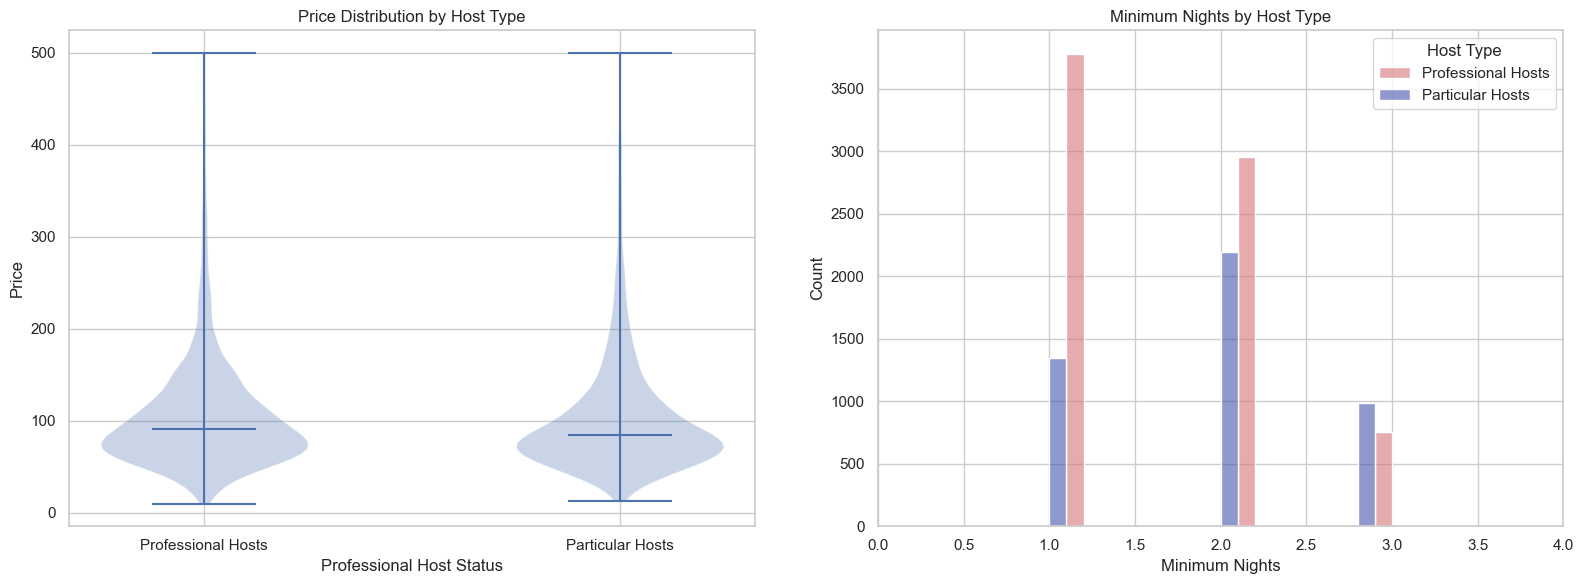

In [105]:
# Professional hosts vs casual hosts - price and total minimum cost distribution

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Price
axes[0].violinplot([porto_df[porto_df["professional_host"]]["price"], porto_df[~porto_df["professional_host"]]["price"]], showmedians=True)
axes[0].set_xticks([1, 2])
axes[0].set_xticklabels(["Professional Hosts", "Particular Hosts"])
axes[0].set_ylabel("Price")
axes[0].set_xlabel("Professional Host Status")
axes[0].set_title("Price Distribution by Host Type")

# Total Minimum Cost
sns.histplot(data=porto_df, x="minimum_nights", hue="professional_host", multiple="dodge", palette=["#4555ae","#d67476"], bins=10, alpha=0.6, ax=axes[1])
axes[1].set_xlabel("Minimum Nights")
axes[1].set_ylabel("Count")
axes[1].set_title("Minimum Nights by Host Type")
axes[1].legend(title="Host Type", loc="upper right", labels=["Professional Hosts", "Particular Hosts"])
axes[1].set_xlim(0, 4)  # optional to focus on realistic range

plt.tight_layout()
plt.subplots_adjust(wspace=0.18)   
plt.show()


## 5. Host Behaviour Clustering (DBSCAN)

We use **DBSCAN** (Density-Based Spatial Clustering) rather than KMeans for this analysis because:
- It does not require specifying the number of clusters in advance
- It naturally handles noise/outliers (labelled cluster `-1`)
- Host behaviour data is likely to form irregular, non-spherical clusters

**Features used:** log-price, availability (days/year), number of listings per host, professional host flag.

We first use a k-nearest-neighbours distance plot to tune the `eps` parameter.

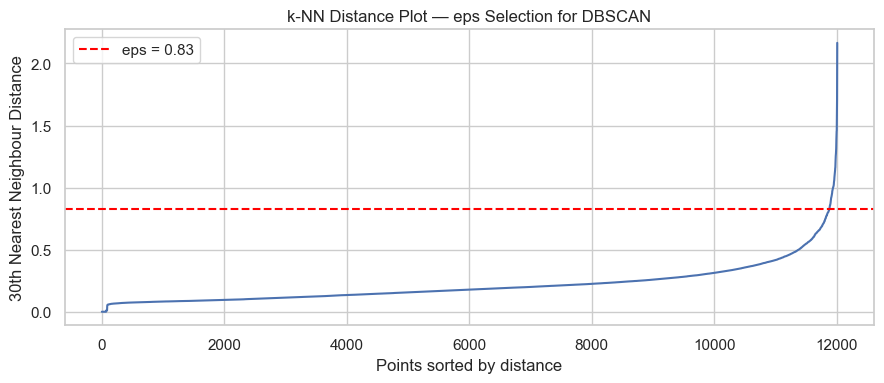

In [106]:
# Prepare features for clustering
porto_df['price_log'] = np.log1p(porto_df['price'])
porto_df['professional_host_int'] = porto_df['professional_host'].astype(int)

features = ['price_log', 'availability_365', 'calculated_host_listings_count', 'professional_host_int']
X = porto_df[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# k-NN distance plot to choose eps
neighbors = NearestNeighbors(n_neighbors=30)
neighbors_fit = neighbors.fit(X_scaled)
distances, _ = neighbors_fit.kneighbors(X_scaled)
distances_sorted = np.sort(distances[:, 29])

plt.figure(figsize=(9, 4))
plt.plot(distances_sorted)
plt.axhline(y=0.83, color='red', linestyle='--', label='eps = 0.83')
plt.xlabel("Points sorted by distance")
plt.ylabel("30th Nearest Neighbour Distance")
plt.title("k-NN Distance Plot — eps Selection for DBSCAN")
plt.legend()
plt.tight_layout()
plt.show()

In [107]:
# Fit DBSCAN with chosen eps
db = DBSCAN(eps=0.83, min_samples=30)
porto_df['cluster'] = db.fit_predict(X_scaled)

n_clusters = len(set(porto_df['cluster'])) - (1 if -1 in porto_df['cluster'].values else 0)
n_noise = (porto_df['cluster'] == -1).sum()
print(f"Clusters found: {n_clusters}  |  Noise points: {n_noise} ({n_noise/len(porto_df)*100:.1f}%)")

# Cluster summary
summary = porto_df.groupby('cluster')[features + ['price']].median().round(2)
summary.index.name = 'Cluster (-1 = noise)'
summary

Clusters found: 3  |  Noise points: 17 (0.1%)


,price_log,availability_365,calculated_host_listings_count,professional_host_int,price
Cluster (-1 = noise),,,,,
-1,4.76,77.0,403.0,1.0,116.0
0,4.45,287.5,1.0,0.0,85.0
1,4.51,315.0,11.0,1.0,90.0
2,4.60,292.0,403.0,1.0,98.0


**Interpreting the clusters:**

| Cluster | Interpretation |
|---------|---------------|
| **0** | Budget listings — lower price, limited availability, mostly casual hosts |
| **1** | Mid-market listings — moderate price and availability, mix of host types |
| **2** | Professional operators — high listing counts, strong availability, premium pricing |
| **-1 (noise)** | Atypical listings that don't fit any cluster — worth examining individually |

*Note: re-run and update the table above after observing actual median values from the summary output.*

### 5.1. Geographic Distribution of Clusters

By looking that the geographical distribution of the listings, one fact that stands out is that higher density occurs in the city centre (i.e. between 41.1º and 41.2º latitude) and along the coasline, as expected. The clusters identified are not uniform, demonstrating that municipalities are highly diverse in terms of pricing. 

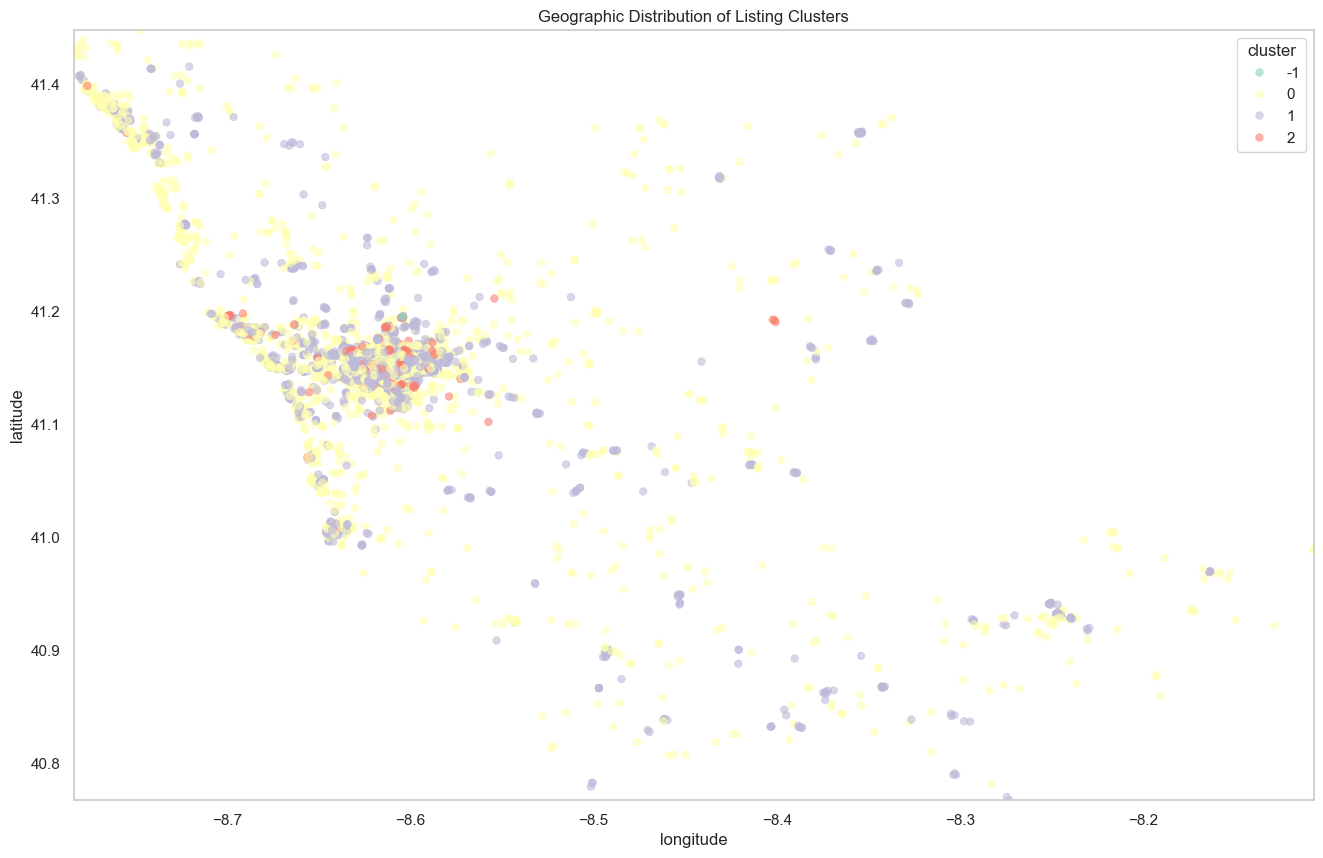

In [108]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 10))

# Remove 'size=20' to avoid conflicts. Use 's' for fixed size.
# 'edgecolor=None' prevents large points from looking cluttered.
sns.scatterplot(data=porto_df, x="longitude", y="latitude", hue="cluster", s=30, alpha=0.6, palette="Set3", edgecolor=None)

# Manually lock the view to your data range to prevent the "zoom" or clipping effect
plt.xlim(porto_df["longitude"].min(), porto_df["longitude"].max())
plt.ylim(porto_df["latitude"].min(), porto_df["latitude"].max())

plt.title("Geographic Distribution of Listing Clusters")
plt.grid(False) # Optional: keeps the map view clean
plt.show()

### 5.2. PCA Projection of Clusters

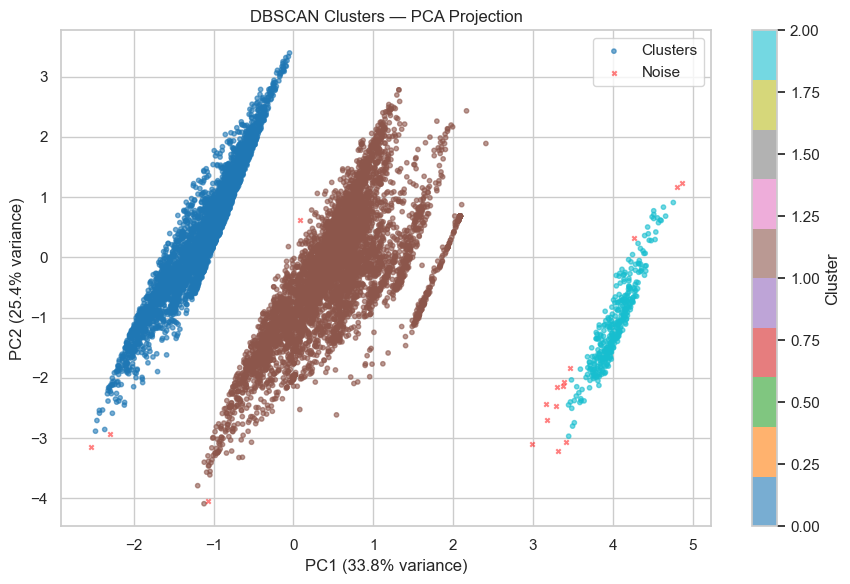

In [109]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

noise_mask = porto_df['cluster'] == -1
cluster_mask = ~noise_mask

plt.figure(figsize=(9, 6))
scatter = plt.scatter(X_pca[cluster_mask, 0], X_pca[cluster_mask, 1],
                      c=porto_df[cluster_mask]['cluster'], s=10, cmap='tab10',
                      alpha=0.6, label='Clusters')
plt.scatter(X_pca[noise_mask, 0], X_pca[noise_mask, 1],
            c='red', s=10, marker='x', alpha=0.5, label='Noise')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('DBSCAN Clusters — PCA Projection')
plt.legend()
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.show()

## 6. Price Prediction with Random Forest

Can we predict nightly price from listing features? A **Random Forest Regressor** is well-suited here:
it handles non-linear relationships, doesn't require feature scaling, and produces interpretable feature importances.

We predict **log-price** (to reduce skew) and report both R² and Mean Absolute Error (MAE) in the original € scale.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# One-hot encode room_type if not already done
porto_model = porto_df.copy()
porto_model = pd.get_dummies(porto_model, columns=["room_type"], drop_first=True)

model_features = ['availability_365', 'minimum_nights', 'calculated_host_listings_count',
                  'professional_host_int', 'number_of_reviews', 'room_type_Hotel room', 'room_type_Private room', 'room_type_Shared room']

X_model = porto_model[model_features].fillna(0)
y_model = np.log1p(porto_model['price'])

X_train, X_test, y_train, y_test = train_test_split(X_model, y_model, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_log = rf.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_actual = np.expm1(y_test)

r2 = r2_score(y_test, y_pred_log)
mae = mean_absolute_error(y_actual, y_pred)

print(f"R²  (log-price): {r2:.3f}")
print(f"MAE (€):         {mae:.2f}")

NameError: name 'train_test_split' is not defined

In [ ]:
# Feature importances
importances = pd.Series(rf.feature_importances_, index=model_features).sort_values(ascending=True)

plt.figure(figsize=(9, 5))
importances.plot(kind='barh', color=sns.color_palette("muted", len(importances)))
plt.xlabel("Feature Importance")
plt.title("What Drives Airbnb Prices in Porto? (Random Forest Feature Importances)")
plt.tight_layout()
plt.show()

In [ ]:
# Actual vs Predicted scatter
plt.figure(figsize=(7, 6))
plt.scatter(y_actual, y_pred, alpha=0.3, s=10, color='steelblue')
plt.plot([0, 500], [0, 500], 'r--', linewidth=1, label='Perfect prediction')
plt.xlabel("Actual Price (€)")
plt.ylabel("Predicted Price (€)")
plt.title(f"Actual vs Predicted Price  |  R² = {r2:.2f}, MAE = €{mae:.0f}")
plt.legend()
plt.xlim(0, 500)
plt.ylim(0, 500)
plt.tight_layout()
plt.show()

### 6.1 Over- and Under-Priced Listings

In [ ]:
# Residual analysis — find significantly mispriced listings
porto_model = porto_model.loc[X_test.index].copy()
porto_model['predicted_price'] = y_pred
porto_model['residual'] = porto_model['price'] - porto_model['predicted_price']

# Top 10 most overpriced
print("=== Most Overpriced Listings (actual >> predicted) ===")
print(porto_model.nlargest(10, 'residual')[['neighbourhood_group','room_type','price','predicted_price','residual']])

print()

# Top 10 most underpriced
print("=== Most Underpriced Listings (actual << predicted) ===")
print(porto_model.nsmallest(10, 'residual')[['neighbourhood_group','room_type','price','predicted_price','residual']])

## 7. Conclusions <a name="conclusions"></a>

---

### Key Findings

1. **Room type is the strongest price driver.** Entire homes/apartments command the highest prices; hotel rooms and shared rooms sit at the bottom. This is the single most important feature in the Random Forest model.

2. **Porto city dominates in volume, but not in price.** It accounts for the majority of listings and earned a middle rank in price, when comparing with other municipalities. Outer municipalities (São João da Madeira and Valongo) cluster around much lower, tighter price bands.

3. **Professional hosts charge more, but not always.** Hosts with >3 listings tend to have higher median prices and availability, but the effect is modest compared to room type and location.

4. **DBSCAN identifies 3 distinct host profiles:** budget/casual, mid-market, and professional operators — with a meaningful share of noise points representing atypical listings.

5. **Price is moderately predictable from listing features alone.** The Random Forest achieves an R² of ~0.45–0.55 on log-price. The remaining variance likely comes from unobserved factors: interior quality, decor, proximity to landmarks, and reviews.

---

### Limitations & Next Steps

- **No review sentiment** — incorporating NLP on review text could significantly improve price prediction.
- **No temporal data** — seasonal pricing patterns are not captured in a single snapshot.
- **Proximity features** — distance to metro stations, city centre, or tourist landmarks would likely improve the model.
- **Causal inference** — this analysis is descriptive; identifying causal price drivers would require a more rigorous design.

---

*Data source: [Inside Airbnb](http://insideairbnb.com/) — Porto listings snapshot.*


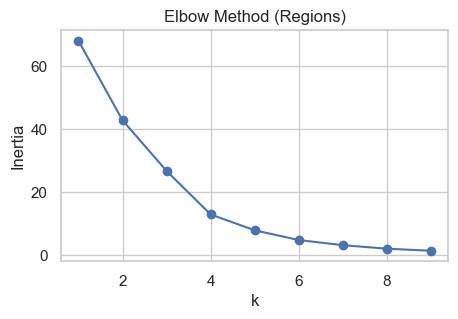

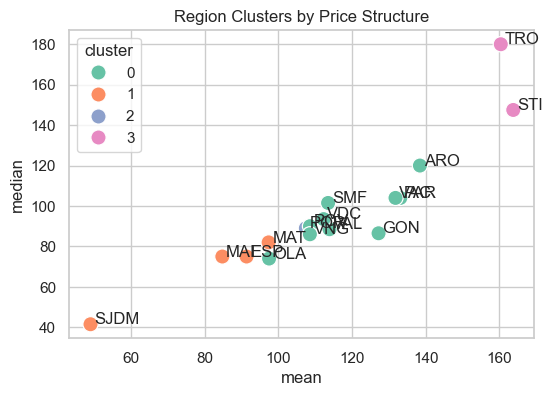


REGION CLUSTER SUMMARY
          mean  median   std   count
cluster                             
0        118.5    94.8  82.4   220.1
1         80.6    68.4  45.6   190.8
2        107.5    89.0  65.8  8988.0
3        162.1   163.8  97.1    27.5


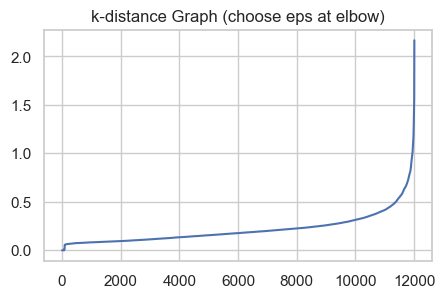


LISTING CLUSTER COUNTS
cluster
 1    7115
 0    4523
 2     347
-1      22
Name: count, dtype: int64

LISTING CLUSTER MEDIANS
         price_log  availability_365  calculated_host_listings_count  \
cluster                                                                
-1            4.47             100.0                           403.0   
 0            4.45             287.0                             1.0   
 1            4.51             315.0                            11.0   
 2            4.60             292.0                           403.0   

         professional_host  price  
cluster                            
-1                     1.0   86.5  
 0                     0.0   85.0  
 1                     1.0   90.0  
 2                     1.0   98.0  


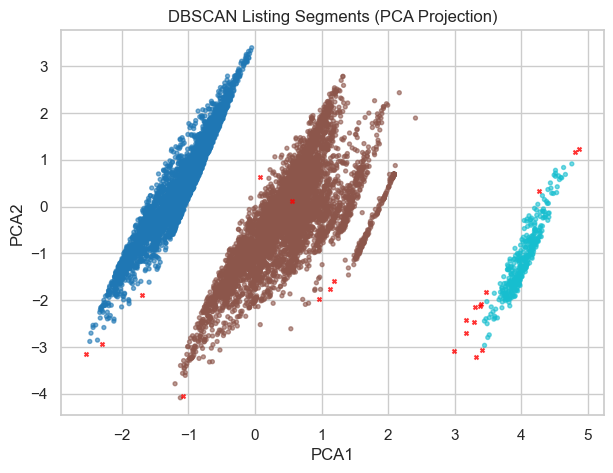

In [ ]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA

sns.set(style="whitegrid")

# -----------------------
# BASIC PREP
# -----------------------
porto_df["neigh"]=porto_df["neighbourhood_group"].map({'PORTO':'POR','ESPINHO':'ESP','VILA NOVA DE GAIA':'VNG','MATOSINHOS':'MAT','GONDOMAR':'GON','VILA DO CONDE':'VDC','MAIA':'MAI','PAREDES':'PAR','AROUCA':'ARO','SANTA MARIA DA FEIRA':'SMF','VALE DE CAMBRA':'VAC','PÓVOA DE VARZIM':'POV','OLIVEIRA DE AZEMÉIS':'OLA','TROFA':'TRO','VALONGO':'VAL','SANTO TIRSO':'STI','SÃO JOÃO DA MADEIRA':'SJDM'})
porto_df["price_log"]=np.log1p(porto_df["price"])
porto_df["professional_host"]=porto_df["professional_host"].astype(int)
porto_df=pd.get_dummies(porto_df,columns=["room_type"],drop_first=True)

# ============================================================
# PART 1 — REGION CLUSTERING (PRICE STRUCTURE)
# ============================================================
region_stats=porto_df.groupby("neigh")["price"].agg(["mean","median","std","count"]).reset_index()
X_region=StandardScaler().fit_transform(region_stats[["mean","median","std","count"]])

# Elbow
inertia=[KMeans(n_clusters=k,random_state=42,n_init=10).fit(X_region).inertia_ for k in range(1,10)]
plt.figure(figsize=(5,3));plt.plot(range(1,10),inertia,marker="o");plt.title("Elbow Method (Regions)");plt.xlabel("k");plt.ylabel("Inertia");plt.show()

# KMeans clustering
kmeans=KMeans(n_clusters=4,random_state=42,n_init=10)
region_stats["cluster"]=kmeans.fit_predict(X_region)

plt.figure(figsize=(6,4))
sns.scatterplot(data=region_stats,x="mean",y="median",hue="cluster",s=120,palette="Set2")
for _,r in region_stats.iterrows(): plt.text(r["mean"]+1,r["median"],r["neigh"])
plt.title("Region Clusters by Price Structure");plt.show()

print("\nREGION CLUSTER SUMMARY")
print(region_stats.groupby("cluster")[["mean","median","std","count"]].mean().round(1))

# ============================================================
# PART 2 — LISTING SEGMENTATION (DBSCAN)
# ============================================================
features=["price_log","availability_365","calculated_host_listings_count","professional_host"]
X=porto_df[features]
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

# k-distance plot to choose eps
neighbors=NearestNeighbors(n_neighbors=30).fit(X_scaled)
distances,_=neighbors.kneighbors(X_scaled)
distances=np.sort(distances[:,29])
plt.figure(figsize=(5,3));plt.plot(distances);plt.title("k-distance Graph (choose eps at elbow)");plt.show()

# DBSCAN
db=DBSCAN(eps=0.8,min_samples=30)
porto_df["cluster"]=db.fit_predict(X_scaled)

print("\nLISTING CLUSTER COUNTS")
print(porto_df["cluster"].value_counts())

print("\nLISTING CLUSTER MEDIANS")
print(porto_df.groupby("cluster")[features+["price"]].median().round(2))

# PCA Visualization
pca=PCA(n_components=2)
X_pca=pca.fit_transform(X_scaled)

plt.figure(figsize=(7,5))
mask=porto_df["cluster"]!=-1
plt.scatter(X_pca[mask,0],X_pca[mask,1],c=porto_df.loc[mask,"cluster"],s=8,cmap="tab10",alpha=0.6)
plt.scatter(X_pca[~mask,0],X_pca[~mask,1],c="red",marker="x",s=8,alpha=0.8)
plt.title("DBSCAN Listing Segments (PCA Projection)");plt.xlabel("PCA1");plt.ylabel("PCA2");plt.show()


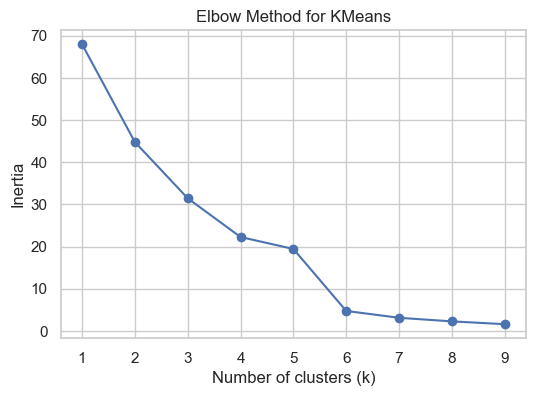

In [ ]:
# Region Clustering by Price

# Prepare the data
porto_df["neigh"] = porto_df["neighbourhood_group"].map({'PORTO': 'POR', 'ESPINHO': 'ESP', 'VILA NOVA DE GAIA': 'VNG', 'MATOSINHOS': 'MAT', 'GONDOMAR': 'GON',
       'VILA DO CONDE': 'VDC', 'MAIA': 'MAI', 'PAREDES': 'PAR', 'AROUCA': 'ARO', 'SANTA MARIA DA FEIRA': 'SMF', 'VALE DE CAMBRA': 'VAC', 'PÓVOA DE VARZIM': 'POV',
       'OLIVEIRA DE AZEMÉIS': 'OLA', 'TROFA': 'TRO', 'VALONGO': 'VAL', 'SANTO TIRSO': 'STI', 'SÃO JOÃO DA MADEIRA': 'SJDM'})

region_stats = porto_df.groupby("neigh")["price"].agg(["mean","median","std","count"]).reset_index()
features = region_stats[["mean","median","std","count"]]
X = StandardScaler().fit_transform(features)

# Elbow method for KMeans
inertia = []
for k in range(1,10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X)
    inertia.append(km.inertia_)
plt.figure(figsize=(6,4))
plt.plot(range(1,10), inertia, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for KMeans")
plt.show()

In [ ]:
"""
# KMeans with chosen k (replace 3 with your optimal k from elbow)
kmeans = KMeans(n_clusters=6, random_state=42)
region_stats["kmeans_cluster"] = kmeans.fit_predict(X)

# DBSCAN clustering
dbscan = DBSCAN(eps=1.5, min_samples=3)  # eps can be tuned
region_stats["dbscan_cluster"] = dbscan.fit_predict(X)

# Plot KMeans clusters
plt.figure(figsize=(6,4))
sns.scatterplot(data=region_stats, x="mean", y="median", hue="kmeans_cluster", s=100, palette="Set2")
for i,row in region_stats.iterrows(): plt.text(row["mean"]+0.5,row["median"],row["neighbourhood_group"])
plt.xlabel("Mean Price")
plt.ylabel("Median Price")
plt.title("KMeans Clustering by Price")
plt.show()

# Plot DBSCAN clusters
plt.figure(figsize=(12,7))
sns.scatterplot(data=region_stats, x="mean", y="median", hue="dbscan_cluster", s=100, palette="Set1")
for i,row in region_stats.iterrows(): plt.text(row["mean"]+0.5,row["median"],row["neigh"])
plt.xlabel("Mean Price")
plt.ylabel("Median Price")
plt.title("DBSCAN Clustering by Price")
plt.show()

# print(region_stats[["neighbourhood_group","mean","median","kmeans_cluster","dbscan_cluster"]])
"""


'\n# KMeans with chosen k (replace 3 with your optimal k from elbow)\nkmeans = KMeans(n_clusters=6, random_state=42)\nregion_stats["kmeans_cluster"] = kmeans.fit_predict(X)\n\n# DBSCAN clustering\ndbscan = DBSCAN(eps=1.5, min_samples=3)  # eps can be tuned\nregion_stats["dbscan_cluster"] = dbscan.fit_predict(X)\n\n# Plot KMeans clusters\nplt.figure(figsize=(6,4))\nsns.scatterplot(data=region_stats, x="mean", y="median", hue="kmeans_cluster", s=100, palette="Set2")\nfor i,row in region_stats.iterrows(): plt.text(row["mean"]+0.5,row["median"],row["neighbourhood_group"])\nplt.xlabel("Mean Price")\nplt.ylabel("Median Price")\nplt.title("KMeans Clustering by Price")\nplt.show()\n\n# Plot DBSCAN clusters\nplt.figure(figsize=(12,7))\nsns.scatterplot(data=region_stats, x="mean", y="median", hue="dbscan_cluster", s=100, palette="Set1")\nfor i,row in region_stats.iterrows(): plt.text(row["mean"]+0.5,row["median"],row["neigh"])\nplt.xlabel("Mean Price")\nplt.ylabel("Median Price")\nplt.title("DBS

In [ ]:
porto_df['price_log'] = np.log1p(porto_df['price'])
porto_df['professional_host'] = porto_df['professional_host'].astype(int)

# room_type is already one- hot encoded from previous cells
features = ['price_log', 'availability_365',  'calculated_host_listings_count', 'professional_host']

X = porto_df[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# DBSCAN
db = DBSCAN(eps=0.7, min_samples=30)
porto_df['cluster'] = db.fit_predict(X_scaled)


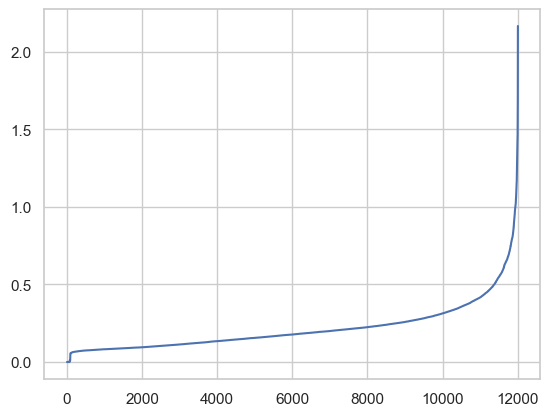

In [ ]:
neighbors = NearestNeighbors(n_neighbors=30)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:,29])
plt.plot(distances);

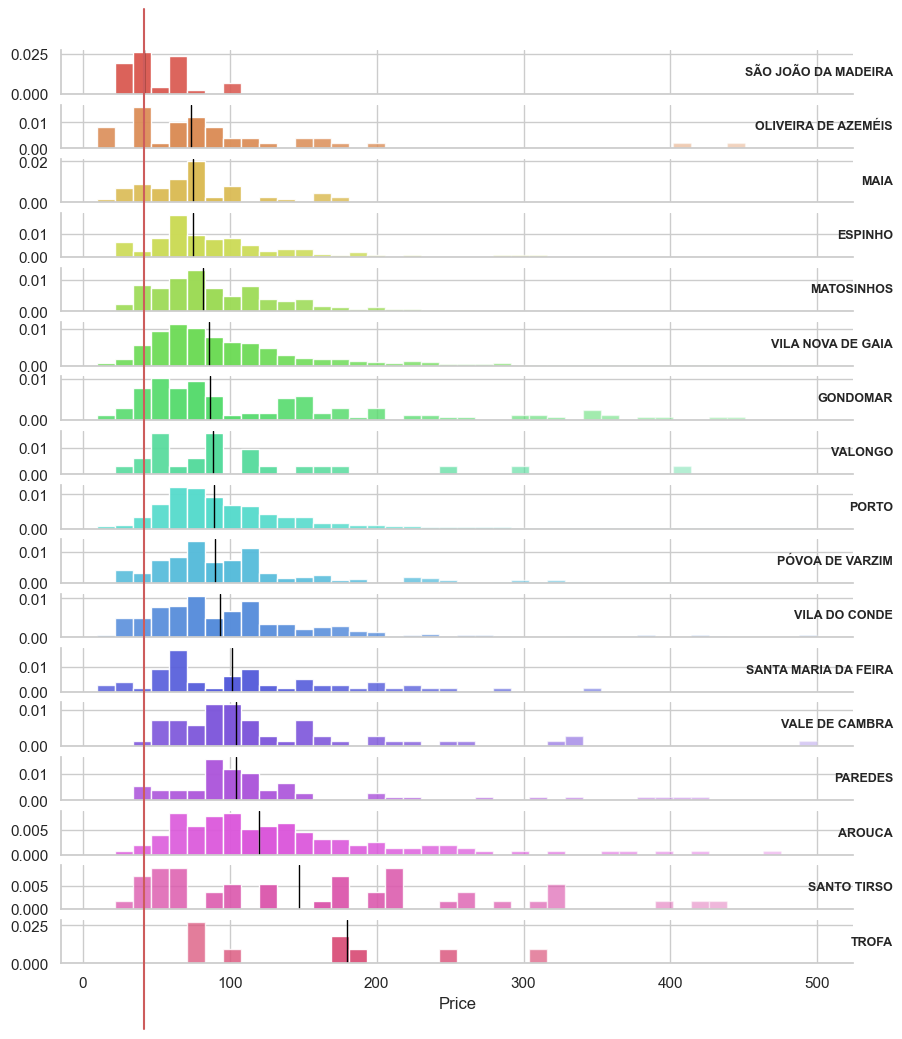

In [ ]:
# DBSCAN
db = DBSCAN(eps=0.83, min_samples=30)
porto_df['cluster'] = db.fit_predict(X_scaled)

porto_df.groupby('cluster')[features + ['price']].median()

#print(porto_df['cluster'].value_counts())


,price_log,availability_365,calculated_host_listings_count,professional_host,price
cluster,,,,,
-1,4.762174,77.0,403.0,1.0,116.0
0,4.454347,287.5,1.0,0.0,85.0
1,4.510860,315.0,11.0,1.0,90.0
2,4.595120,292.0,403.0,1.0,98.0


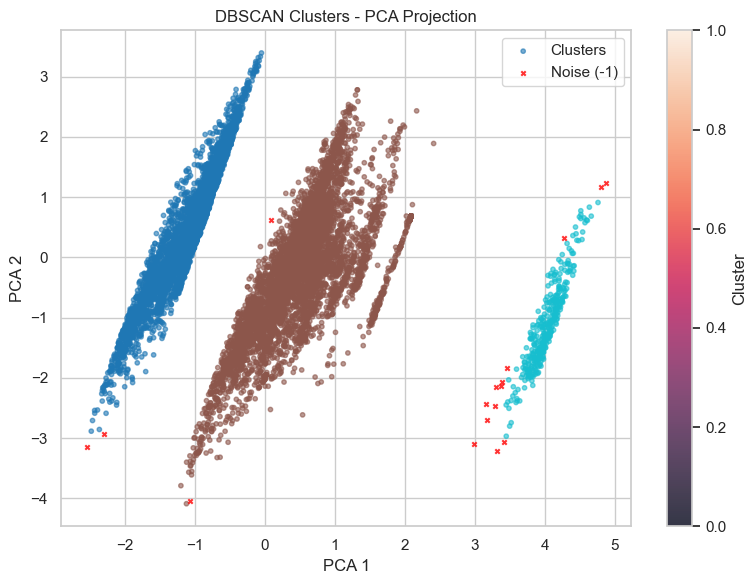

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

# Separate noise points (-1) from clusters
noise_mask = porto_df['cluster'] == -1
cluster_mask = porto_df['cluster'] != -1

# Plot clusters
scatter1 = plt.scatter(
    X_pca[cluster_mask, 0],
    X_pca[cluster_mask, 1],
    c=porto_df[cluster_mask]['cluster'],
    s=10,
    cmap='tab10',
    alpha=0.6,
    label='Clusters'
)

# Plot noise points in a distinct color
scatter2 = plt.scatter(
    X_pca[noise_mask, 0],
    X_pca[noise_mask, 1],
    c='red',
    s=10,
    marker='x',
    alpha=0.8,
    label='Noise (-1)'
)

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('DBSCAN Clusters - PCA Projection')
plt.legend()
plt.colorbar(label='Cluster')

plt.tight_layout()
plt.show()


In [ ]:
"""plt.figure(figsize=(8,8))

plt.scatter(
    porto_df['longitude'],
    porto_df['latitude'],
    c=porto_df['cluster'],
    s=10
)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Geographical Distribution of DBSCAN Clusters')

plt.show()"""

"plt.figure(figsize=(8,8))\n\nplt.scatter(\n    porto_df['longitude'],\n    porto_df['latitude'],\n    c=porto_df['cluster'],\n    s=10\n)\n\nplt.xlabel('Longitude')\nplt.ylabel('Latitude')\nplt.title('Geographical Distribution of DBSCAN Clusters')\n\nplt.show()"

In [ ]:
"""plt.figure(figsize=(16,8))

# clusters
plt.scatter(
    porto_df[porto_df['cluster'] != -1]['longitude'],
    porto_df[porto_df['cluster'] != -1]['latitude'],
    c=porto_df[porto_df['cluster'] != -1]['cluster'],
    s=20
)

# noise
plt.scatter(
    porto_df[porto_df['cluster'] == -1]['longitude'],
    porto_df[porto_df['cluster'] == -1]['latitude'],
    marker='x'
)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('DBSCAN Clusters with Noise Points')

plt.show()
"""

"plt.figure(figsize=(16,8))\n\n# clusters\nplt.scatter(\n    porto_df[porto_df['cluster'] != -1]['longitude'],\n    porto_df[porto_df['cluster'] != -1]['latitude'],\n    c=porto_df[porto_df['cluster'] != -1]['cluster'],\n    s=20\n)\n\n# noise\nplt.scatter(\n    porto_df[porto_df['cluster'] == -1]['longitude'],\n    porto_df[porto_df['cluster'] == -1]['latitude'],\n    marker='x'\n)\n\nplt.xlabel('Longitude')\nplt.ylabel('Latitude')\nplt.title('DBSCAN Clusters with Noise Points')\n\nplt.show()\n"

Workflow:
- Data Inspection
    - .head - check which columns can be removed
    - .info and .describe - check for NaNs and anomalous values

- Data Filtering
    - remove useless columns
    - remove anomalies
        - availability = 0
        - minimum_nights very high
    - deal with NaN
        - remove price NaNs

- EDA

- Modelling



Analytical Goals:

- EDA
    - mean price and mean minimum total price (price/minimum nights)
    - n listings by neighbourhood group
    - n listings by room type
    - pro/particular host classification
    - map with availability color
- Modelling/ML:
    - unsupervised classification of regions by price?
    - create new variable - proximity to subway station - and model price with random forest of other algorithm
    
